In [1]:
import os
import json
import random
import torch
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split

In [3]:
base_dir = r'D:\Courses\Fall 2025\CS 4824\Capstone Project\Data'
os.chdir(base_dir)
csv_path = r"imageslabels.csv"
json_path = r"classes.json"
image_dir = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\images"

In [20]:
df = pd.read_csv(csv_path)
with open(json_path, 'r') as f:
    label_map = json.load(f)

print("CSV preview:")
print(df.head())
print("\nJSON label map:")
print(label_map)

CSV preview:
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

JSON label map:
{'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


In [21]:
subfolders = ["train", "val", "test"]
for folder in subfolders:
    folder_path = os.path.join(base_dir, folder)
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exist_ok=True)
        print(f"✅ Created folder: {folder_path}")
    else:
        print(f"📁 Already exists: {folder_path}")

print("\nAll required folders are ready!")

✅ Created folder: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train
✅ Created folder: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\val
✅ Created folder: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\test

All required folders are ready!


In [22]:
label_map = {int(k): v for k, v in label_map.items()}
df['class_name'] = df['label'].map(label_map)

In [23]:
df = df.dropna(subset=['class_name']).reset_index(drop=True)

print("✅ Sample data:")
print(df.head())
print(df.shape)

✅ Sample data:
         image_id  label                           class_name
0  1000015157.jpg      0       Cassava Bacterial Blight (CBB)
1  1000201771.jpg      3         Cassava Mosaic Disease (CMD)
2   100042118.jpg      1  Cassava Brown Streak Disease (CBSD)
3  1000723321.jpg      1  Cassava Brown Streak Disease (CBSD)
4  1000812911.jpg      3         Cassava Mosaic Disease (CMD)
(21397, 3)


In [24]:
image_files = os.listdir(image_dir) # Make a list of all images in the folder
print("Total images found in folder:", len(image_files))

Total images found in folder: 17938


In [26]:
print("Total images found in folder:", len(image_files))
df_filtered = df[df['image_id'].isin(image_files)].reset_index(drop=True) # drops rows from CSV that doesn't have the images
print("✅ Rows before filtering:", len(df))
print("✅ Rows after filtering:", len(df_filtered))
print("🗑️ Rows removed (missing images):", len(df) - len(df_filtered))

filtered_csv_path = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\labels_filtered.csv"
df_filtered.to_csv(filtered_csv_path, index=False) # Creates the CSV with only those those with images
print("✅ Clean CSV saved at:", filtered_csv_path)

Total images found in folder: 17938
✅ Rows before filtering: 21397
✅ Rows after filtering: 17938
🗑️ Rows removed (missing images): 3459
✅ Clean CSV saved at: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\labels_filtered.csv


In [27]:
df_finalized = pd.read_csv(filtered_csv_path)

In [6]:
src_folder = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\images"
aug_folder = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images"
os.makedirs(aug_folder, exist_ok=True)

In [32]:
image_size = (224, 224)      # Optimum image size for ResNet50
rotation_range = 10          # rotate between -10° and +10°
rotation_prob = 0.6          # 60% chance to rotate
flip_prob = 0.25             # only 25% chance to flip
brightness_prob = 0.3        # 30% chance to change brightness
contrast_prob = 0.25         # 25% chance to change contrast
brightness_range = (0.8, 1.1)
contrast_range   = (0.8, 1.1)

# --- Get all image files ---
image_files = [f for f in os.listdir(src_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
total_images = len(image_files)
print(f"Total images found: {total_images}")

# --- Process images ---
i = 0
for filename in image_files:
    src_path = os.path.join(src_folder, filename)
    save_path = os.path.join(aug_folder, filename)

    i += 1

    # Skip if image already exists in aug_folder
    if os.path.exists(save_path):
        print(f"⏩ Skipping {filename} (already exists)")
        continue

    try:
        img = Image.open(src_path).convert("RGB")

        # --- Always resize ---
        img = img.resize(image_size)

        # --- Random rotation (60% chance) ---
        if random.random() < rotation_prob:
            angle = random.uniform(-rotation_range, rotation_range)
            img = img.rotate(angle)

        # --- Random flip (25% chance) ---
        if random.random() < flip_prob:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        # --- Random brightness (50% chance) ---
        if random.random() < brightness_prob:
            enhancer = ImageEnhance.Brightness(img)
            factor = random.uniform(*brightness_range)
            img = enhancer.enhance(factor)

        # --- Random contrast (50% chance) ---
        if random.random() < contrast_prob:
            enhancer = ImageEnhance.Contrast(img)
            factor = random.uniform(*contrast_range)
            img = enhancer.enhance(factor)

        # --- Save result ---
        img.save(save_path)
        print(f"{i}/{total_images} ✅ Saved: {filename}")

    except Exception as e:
        print(f"⚠️ Error with {filename}: {e}")


print("\n✅ All images augmented and saved in:", aug_folder)


Total images found: 17938
1/17938 ✅ Saved: 157078263.jpg
2/17938 ✅ Saved: 1574893536.jpg
3/17938 ✅ Saved: 1575013487.jpg
4/17938 ✅ Saved: 1576606254.jpg
5/17938 ✅ Saved: 1579761476.jpg
6/17938 ✅ Saved: 1581274070.jpg
7/17938 ✅ Saved: 1583452886.jpg
8/17938 ✅ Saved: 1586131534.jpg
9/17938 ✅ Saved: 159163820.jpg
10/17938 ✅ Saved: 1593185834.jpg
11/17938 ✅ Saved: 1593622565.jpg
12/17938 ✅ Saved: 159364760.jpg
13/17938 ✅ Saved: 1593671887.jpg
14/17938 ✅ Saved: 1593718763.jpg
15/17938 ✅ Saved: 1594306558.jpg
16/17938 ✅ Saved: 1594317361.jpg
17/17938 ✅ Saved: 1594527839.jpg
18/17938 ✅ Saved: 1595079320.jpg
19/17938 ✅ Saved: 1595085512.jpg
20/17938 ✅ Saved: 1595096662.jpg
21/17938 ✅ Saved: 1595141360.jpg
22/17938 ✅ Saved: 1595485153.jpg
23/17938 ✅ Saved: 1595574343.jpg
24/17938 ✅ Saved: 1595577438.jpg
25/17938 ✅ Saved: 1595866872.jpg
26/17938 ✅ Saved: 1595991978.jpg
27/17938 ✅ Saved: 1596196838.jpg
28/17938 ✅ Saved: 1596278382.jpg
29/17938 ✅ Saved: 1596461528.jpg
30/17938 ✅ Saved: 1596468225.

In [38]:
train_df, temp_df = train_test_split(df_finalized, test_size=0.25, stratify=df_finalized['class_name'], random_state=60)
val_df, test_df = train_test_split(temp_df, test_size=0.4, stratify=temp_df['class_name'], random_state=60)

dataframes_to_save = {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df
}
final_splits = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Processed_CSVs"

os.makedirs(final_splits, exist_ok=True)

for name, df_to_save in dataframes_to_save.items():
    # Construct the full file path, including the .csv extension
    file_path = os.path.join(final_splits, name + ".csv")
    
    # Save the current dataframe to the constructed path
    df_to_save.to_csv(file_path, index=False)
    
    print(f"Successfully saved {file_path}")


Successfully saved D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Processed_CSVs\train_df.csv
Successfully saved D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Processed_CSVs\val_df.csv
Successfully saved D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Processed_CSVs\test_df.csv


In [47]:
print(f"--- Summary for df_finalized ---")
print(f"Shape: {df_finalized.shape}")

print("\n--- Info ---")
df_finalized.info()

print(f"\n--- Class Distribution ({name}) ---")
print(df_finalized['class_name'].value_counts(normalize=True))
print("-" * 30 + "\n")

for name, df in dataframes_to_save.items():
    print(f"--- Summary for {name} ---")
    print(f"Shape: {df.shape}")
    
    # General Information (Data Types, Non-Null Counts)
    print("\n--- Info ---")
    df.info()
    
    # Descriptive Statistics for Numerical Columns
    print(f"\n--- Numerical Stats ({name}) ---")
    # Using .T to transpose the output for easier reading
    print(df.describe().T)
    
    # Class Distribution to check stratification
    print(f"\n--- Class Distribution ({name}) ---")
    print(df['class_name'].value_counts(normalize=True))
    print("-" * 30 + "\n")



--- Summary for df_finalized ---
Shape: (17938, 3)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17938 entries, 0 to 17937
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    17938 non-null  object
 1   label       17938 non-null  int64 
 2   class_name  17938 non-null  object
dtypes: int64(1), object(2)
memory usage: 420.5+ KB

--- Class Distribution (test_df) ---
class_name
Cassava Mosaic Disease (CMD)           0.614729
Healthy                                0.120749
Cassava Green Mottle (CGM)             0.111105
Cassava Brown Streak Disease (CBSD)    0.102074
Cassava Bacterial Blight (CBB)         0.051344
Name: proportion, dtype: float64
------------------------------

--- Summary for train_df ---
Shape: (13453, 3)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 13453 entries, 14604 to 17230
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------  

In [40]:
splits = {"train": train_df, "val": val_df, "test": test_df}

subfolder = ["train", "val", "test"]

for split_name in subfolder:
    i = 1
    # pick the right dataframe for each split
    if split_name == "train":
        split_data = train_df
    elif split_name == "val":
        split_data = val_df
    else:
        split_data = test_df

    print(f"\nCopying images for: {split_name}")

    class_folder = os.path.join(base_dir, split_name)

    if not os.path.exists(class_folder):
        os.makedirs(class_folder, exist_ok=True)
        print(f"✅ Created folder: {class_folder}")
    else:
        print(f"📁 Already exists: {class_folder}")

    # Go through every row (each image)
    for _, row in split_data.iterrows():
        src_path = os.path.join(aug_folder, row['image_id'])       # original image
        dst_path = os.path.join(class_folder, row['image_id'])    # where to copy
        print(f"{i}/{len(split_data)} ✅ Copying {src_path} to {dst_path}")
        i += 1
        shutil.copy(src_path, dst_path)                           # copy the image

    print(f"✅ Finished {split_name} ({len(split_data)} images)")

print("✅ Dataset split completed.")


Copying images for: train
📁 Already exists: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train
1/13453 ✅ Copying D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images\4252236416.jpg to D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train\4252236416.jpg
2/13453 ✅ Copying D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images\1658661727.jpg to D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train\1658661727.jpg
3/13453 ✅ Copying D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images\736896439.jpg to D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train\736896439.jpg
4/13453 ✅ Copying D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images\3241869544.jpg to D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train\3241869544.jpg
5/13453 ✅ Copying D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images\3191863856.jpg to D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\train\3191863856.jpg
6/13453 ✅ Copying D:\Courses\Fall 2025\CS 4824\Cap

✅ Dataset loaded successfully.
         image_id  label                           class_name
0   157078263.jpg      3         Cassava Mosaic Disease (CMD)
1  1574893536.jpg      3         Cassava Mosaic Disease (CMD)
2  1575013487.jpg      3         Cassava Mosaic Disease (CMD)
3  1576606254.jpg      0       Cassava Bacterial Blight (CBB)
4  1579761476.jpg      1  Cassava Brown Streak Disease (CBSD)


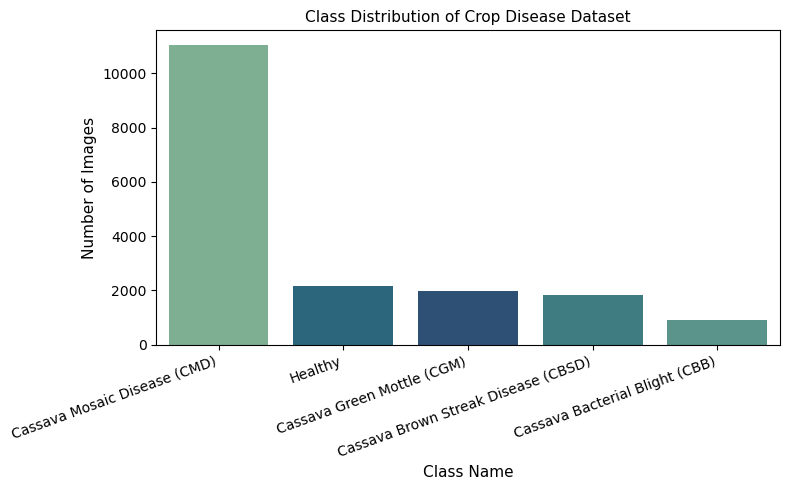

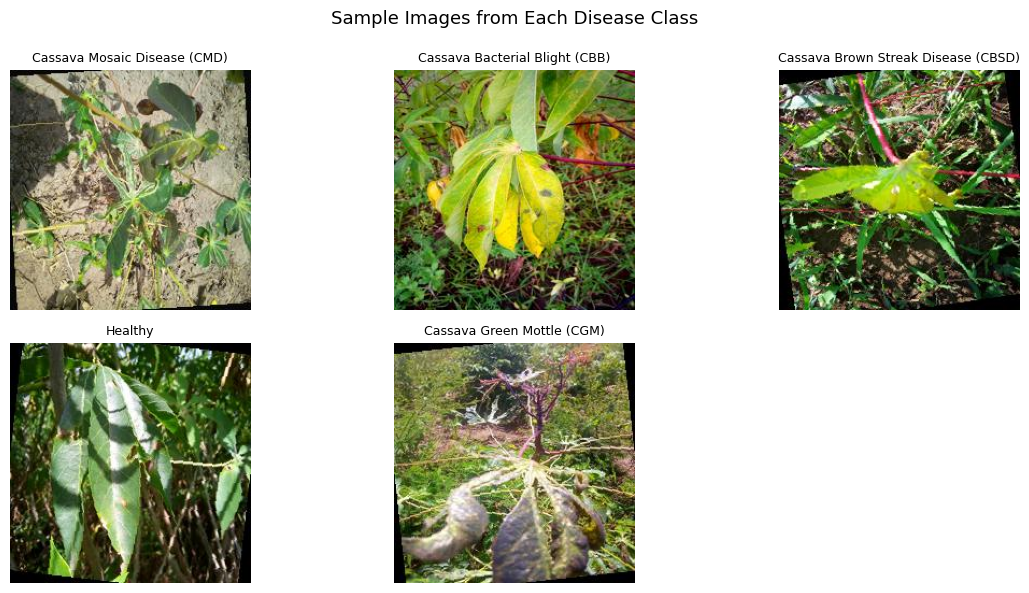

In [14]:
csv_path = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\labels_filtered.csv"
image_dir = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\aug_images"

df = pd.read_csv(csv_path)
print("✅ Dataset loaded successfully.")
print(df.head())

# <------ Class distribution bar plot ---------->

plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df,
    x='class_name',
    hue='class_name',        
    order=df['class_name'].value_counts().index,
    palette="crest",
    legend=False               # to hide duplicate legend
)
plt.title("Class Distribution of Crop Disease Dataset", fontsize=11)
plt.xlabel("Class Name", fontsize=11)
plt.ylabel("Number of Images", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

# <------ Sample image mosaic (1 per class) ---------->

unique_classes = df['class_name'].unique()
n_classes = len(unique_classes)
plt.figure(figsize=(12, 6))

for i, cls in enumerate(unique_classes):
    # Get one sample image from this class
    sample_img = df[df['class_name'] == cls].iloc[0]['image_id']
    img_path = os.path.join(image_dir, sample_img)
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        plt.subplot(2, int(np.ceil(n_classes/2)), i+1)
        plt.imshow(img)
        plt.title(cls, fontsize=9)
        plt.axis('off')

plt.suptitle("Sample Images from Each Disease Class", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("sample_images.png", dpi=300)
plt.show()

## Model Training Starts Here

In [39]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import pandas as pd
from tqdm import tqdm
import time

In [27]:
# All local dataset paths
image_root = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data"
csv_root = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Processed_CSVs"

model_root = os.path.join(image_root, "Saved_Models")
os.makedirs(model_root, exist_ok=True)

train_csv = os.path.join(csv_root, "train_df.csv")
val_csv   = os.path.join(csv_root, "val_df.csv")
test_csv  = os.path.join(csv_root, "test_df.csv")

train_dir = os.path.join(image_root, "train")
val_dir   = os.path.join(image_root, "valid")
test_dir  = os.path.join(image_root, "test")

batch_size = 32
num_classes = 5
num_epochs = 40
learning_rate = 0.001
weight_decay = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [28]:
#TRANSFORMS (ImageNet normalization)
image_size = 224
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [29]:
# <---------- Dataset Loading --------->
class CassavaDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

train_data = CassavaDataset(train_csv, train_dir, transform)
val_data   = CassavaDataset(val_csv, val_dir, transform)
test_data  = CassavaDataset(test_csv, test_dir, transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader   = DataLoader(val_data, batch_size=batch_size,num_workers=0, pin_memory = True)
test_loader  = DataLoader(test_data, batch_size=batch_size, num_workers=0, pin_memory = True)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 13453 | Val: 2691 | Test: 1794


In [30]:
#<-------- Function to train models --------->

def train_model(model, criterion, optimizer, num_epochs, model_name):
    model_dir = os.path.join(model_root, model_name)
    os.makedirs(model_dir, exist_ok=True)

    best_acc = 0.0
    start_time = time.time()
    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            dataloader = train_loader if phase == 'train' else val_loader
            running_loss, running_corrects = 0.0, 0
            
            # tqdm progress bar for each phase
            
            for inputs, labels in tqdm(dataloader, desc=f"{phase.upper()}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                
            # Compute epoch metrics
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)
            print(f"{phase} → Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # Store metrics
            if phase == 'train':
                history['epoch'].append(epoch + 1)
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Saves best model
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_path = os.path.join(model_dir, f"{model_name}_best.pth")
                    torch.save(model.state_dict(), best_path)
                    print(f"💾 Saved best model: {best_path}")

    elapsed = (time.time() - start_time) / 60
    print(f"\n Training Finished in {elapsed:.1f} min | Best Val Acc: {best_acc:.4f}")

    # Save history
    hist_path = os.path.join(model_dir, f"{model_name}_history.csv")
    pd.DataFrame(history).to_csv(hist_path, index=False)

    # Save logs
    params_dict = {
        "num_epochs": num_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "optimizer": "Adam",
        "batch_size": batch_size,
        "image_size": image_size,
        "num_classes": num_classes
    }
    with open(os.path.join(model_dir, f"{model_name}_params.json"), "w") as f:
        json.dump(params_dict, f, indent=4)

    return model

In [31]:
# <----------- EVALUATION FUNCTION ------------>

def evaluate_model(model, dataloader, model_name):
    model_dir = os.path.join(model_root, model_name)
    model.eval()
    all_labels, all_preds = [], []
    start = time.time()

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Evaluating {model_name}"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    elapsed = (time.time() - start)
    acc = 100 * (np.array(all_preds) == np.array(all_labels)).mean()

    # Save classification report
    report = classification_report(all_labels, all_preds, digits=4, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(model_dir, f"{model_name}_classification_report.csv"))

    # Save summary
    with open(os.path.join(model_dir, "test_summary.txt"), "w") as f:
        f.write(f"Test Accuracy: {acc:.2f}%\n")
        f.write(f"Inference Time (sec): {elapsed:.2f}\n")

    print(f" {model_name} Test Accuracy: {acc:.2f}%")
    print(f" Inference Time: {elapsed:.2f} sec for {len(all_labels)} samples")

In [ ]:
# <----------- MODEL 1: RESNET-50 -------------->
print("\n Starting training: ResNet-50")
resnet50 = models.resnet50(pretrained=True)
for param in resnet50.parameters():
    param.requires_grad = False # freeze feature extractor
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_ftrs, num_classes)
)
resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet50.parameters(), lr=learning_rate, weight_decay=weight_decay)
train_model(resnet50, criterion, optimizer_resnet, num_epochs, "resnet50")

# <----------- MODEL 2: EFFICIENTNET-B4 --------------> 

print("\n Starting training: EfficientNet-B4")
efficientnet_b4 = models.efficientnet_b4(pretrained=True)
for param in efficientnet_b4.parameters():
    param.requires_grad = False
num_ftrs = efficientnet_b4.classifier[1].in_features
efficientnet_b4.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_ftrs, num_classes)
)
efficientnet_b4 = efficientnet_b4.to(device)

optimizer_eff = optim.Adam(efficientnet_b4.parameters(), lr=learning_rate, weight_decay=weight_decay)
train_model(efficientnet_b4, criterion, optimizer_eff, num_epochs, "efficientnet_b4")

#<---------- TEST EVALUATION ----------->

print("\n Evaluating both models on test set...")
evaluate_model(resnet50, test_loader, "ResNet50")
evaluate_model(efficientnet_b4, test_loader, "EfficientNetB4")

print("\n All training complete! Organized results in:")
print(model_root)

## Visualization of trained models

In [47]:
model_root = r"D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Saved_Models"

# Load history CSVs
resnet_hist = pd.read_csv(os.path.join(model_root, "resnet50", "resnet50_history.csv"))
eff_hist    = pd.read_csv(os.path.join(model_root, "efficientnet_b4", "efficientnet_b4_history.csv"))

resnet_hist['model'] = 'ResNet50'
eff_hist['model']    = 'EfficientNet-B4'

hist_all = pd.concat([resnet_hist, eff_hist])

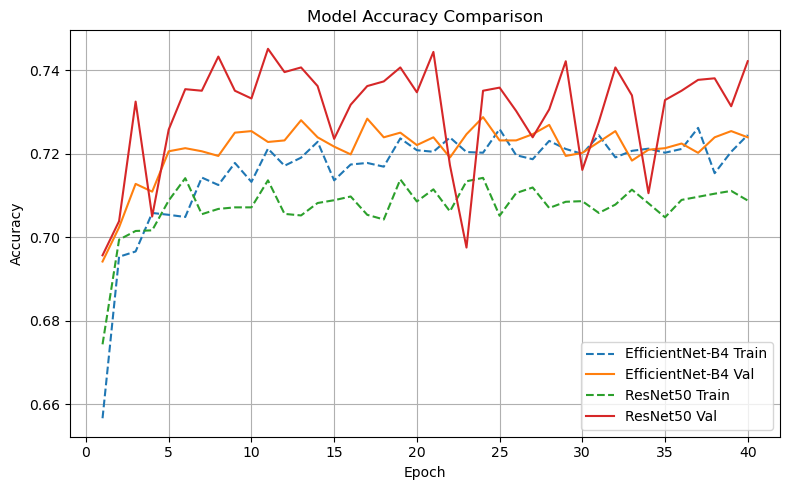

In [54]:
#Model Accuracy Comparision

plt.figure(figsize=(8,5))
for model_name, df in hist_all.groupby('model'):
    plt.plot(df['epoch'], df['train_acc'], '--', label=f'{model_name} Train')
    plt.plot(df['epoch'], df['val_acc'], label=f'{model_name} Val')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = os.path.join(model_root, "accuracy_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

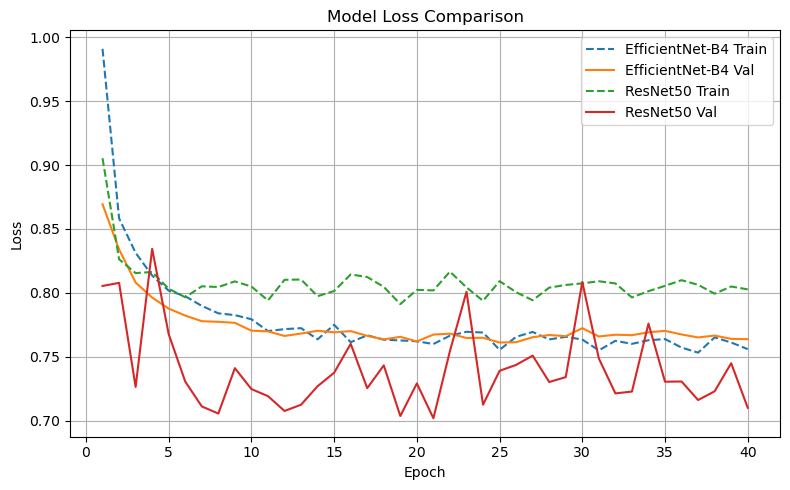

In [55]:
#Model Loss Comparision

plt.figure(figsize=(8,5))
for model_name, df in hist_all.groupby('model'):
    plt.plot(df['epoch'], df['train_loss'], '--', label=f'{model_name} Train')
    plt.plot(df['epoch'], df['val_loss'], label=f'{model_name} Val')

plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = os.path.join(model_root, "Loss_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

In [50]:
# Model training summary Statistics
summary = hist_all.groupby('model')[['val_acc', 'val_loss']].agg(['max', 'min'])
print(summary)

                  val_acc            val_loss          
                      max       min       max       min
model                                                  
EfficientNet-B4  0.728725  0.694166  0.869306  0.761252
ResNet50         0.745076  0.695652  0.834439  0.702043


In [51]:
report_res = pd.read_csv(os.path.join(model_root, "resnet50", "resnet50_classification_report.csv"))
report_eff = pd.read_csv(os.path.join(model_root, "efficientnet_b4", "efficientnet_b4_classification_report.csv"))
print("Performance Stats by class of ResNet50:")
print(report_res.head())
print("\n")
print("Performance Stats by class of EfficientnetB4:")
print(report_eff.head())

Performance Stats by class of ResNet50:
  Unnamed: 0  precision    recall  f1-score  support
0          0   0.369565  0.554348  0.443478     92.0
1          1   0.555556  0.327869  0.412371    183.0
2          2   0.512000  0.321608  0.395062    199.0
3          3   0.821514  0.934723  0.874470   1103.0
4          4   0.559524  0.433180  0.488312    217.0


Performance Stats by class of EfficientnetB4:
  Unnamed: 0  precision    recall  f1-score  support
0          0   0.418182  0.250000  0.312925     92.0
1          1   0.535948  0.448087  0.488095    183.0
2          2   0.520548  0.190955  0.279412    199.0
3          3   0.786378  0.921124  0.848434   1103.0
4          4   0.479638  0.488479  0.484018    217.0


In [52]:
def plot_confusion_matrix(model, dataloader, model_name, class_names):
    model_dir = os.path.join(model_root, model_name)
    model.eval()

    all_labels, all_preds = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Confusion Matrix ({model_name})"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    acc = (np.array(all_labels) == np.array(all_preds)).mean() * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'{model_name} Confusion Matrix\nAccuracy: {acc:.2f}%')
    plt.tight_layout()

    # Save figure
    save_path = os.path.join(model_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f" Saved confusion matrix: {save_path}")

C:\Users\rosha\AppData\Local\Temp\ipykernel_23664\390566731.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50.load_state_dict(torch.load(resnet50_path, map_locati

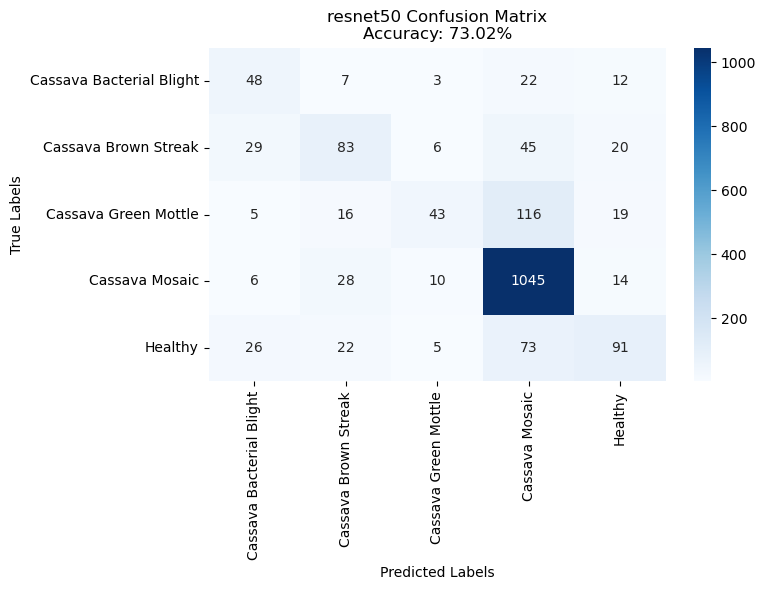

 Saved confusion matrix: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Saved_Models\resnet50\resnet50_confusion_matrix.png


Confusion Matrix (efficientnet_b4): 100%|██████████████████████████████████████████████| 57/57 [00:07<00:00,  8.03it/s]


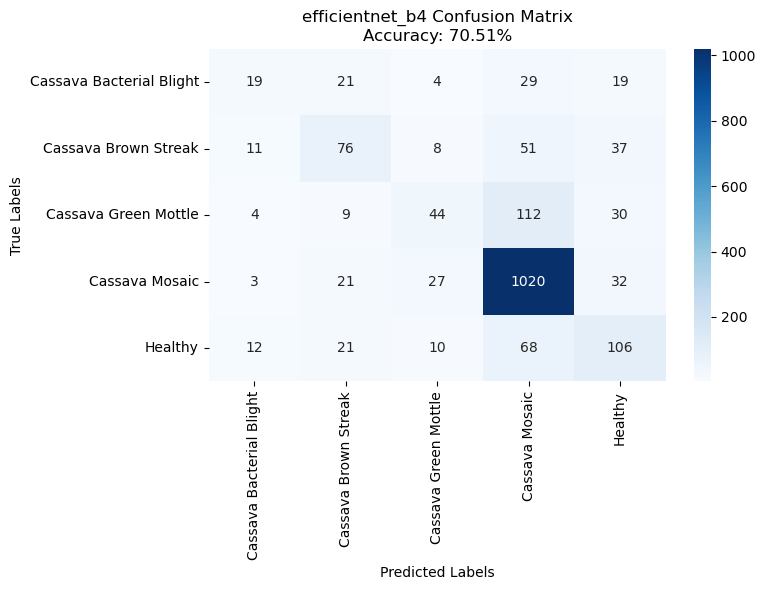

 Saved confusion matrix: D:\Courses\Fall 2025\CS 4824\Capstone Project\Data\Saved_Models\efficientnet_b4\efficientnet_b4_confusion_matrix.png


In [53]:
class_names = ['Cassava Bacterial Blight', 'Cassava Brown Streak', 
               'Cassava Green Mottle', 'Cassava Mosaic', 'Healthy']

# Reload best models before evaluation
resnet50_path = os.path.join(model_root, "resnet50", "resnet50_best.pth")
effb4_path    = os.path.join(model_root, "efficientnet_b4", "efficientnet_b4_best.pth")

# Reload weights
resnet50.load_state_dict(torch.load(resnet50_path, map_location=device))
efficientnet_b4.load_state_dict(torch.load(effb4_path, map_location=device))

# Generate confusion matrices
plot_confusion_matrix(resnet50, test_loader, "resnet50", class_names)
plot_confusion_matrix(efficientnet_b4, test_loader, "efficientnet_b4", class_names)